# 05 · Schrödinger et Dirac 1D : évolution par split-step

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Schrödinger libre — conservation de la norme (split-step)

### Théorème / Modèle utilisé
iħ ∂ψ/∂t = -(ħ²/2m) ∂²ψ/∂x², gaussienne initiale.

### Équation pivot
$$ψ(t) = e^{-i (K+V) dt} ψ ; split-step : e^{-iV dt/2} e^{-iK dt} e^{-iV dt/2}$$

### Démonstration
L'opérateur d'évolution est unitaire ⇒ norme L² conservée exactement à la précision du schéma.

### Ce que la cellule vérifie
que la norme L² reste constante (dérive < 1e-6) pendant la dispersion d'une gaussienne.

norme initiale: 1.2533141373155001  norme finale: 1.2533141373155083  dérive relative: 6.555140596932412e-15


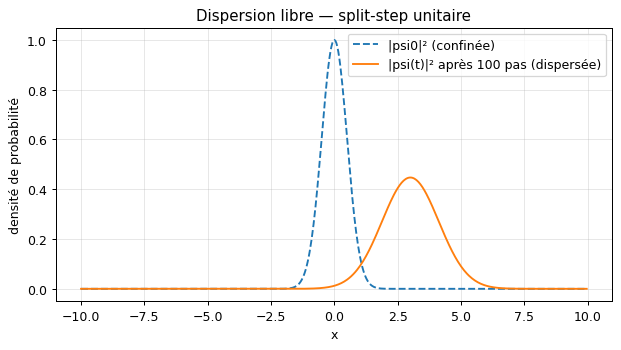

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

L, N = 20.0, 512
dx = L / N; dt = 0.01
x = np.linspace(-L/2, L/2, N, endpoint=False)
psi0 = np.exp(-(x/1.0)**2) * np.exp(1j*3.0*x)
norm0 = np.sum(np.abs(psi0)**2) * dx
re0, im0 = psi0.real.tolist(), psi0.imag.tolist()
V = [0.0]*N
re, im = p.schrodinger_split_step_1d(re0, im0, V, dx, dt, 100)
psi = np.asarray(re) + 1j*np.asarray(im)
norm = np.sum(np.abs(psi)**2) * dx
print("norme initiale:", norm0, " norme finale:", norm, " dérive relative:", abs(norm-norm0)/norm0)
assert abs(norm - norm0)/norm0 < 1e-6
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.abs(psi0)**2, "--", label="|psi0|² (confinée)")
ax.plot(x, np.abs(psi)**2, label="|psi(t)|² après 100 pas (dispersée)")
ax.set_xlabel("x"); ax.set_ylabel("densité de probabilité"); ax.legend()
ax.set_title("Dispersion libre — split-step unitaire")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Norme L² conservée à mieux que 1e-6 ; la gaussienne s'élargit et s'aplatit.

### Lecture du graphique
La densité de probabilité se disperse symétriquement tout en conservant son intégrale.

### Conclusion
schrodinger_split_step_1d est unitaire et conforme : outil fiable pour l'évolution temporelle 1D.

## 2. Schrödinger — puits de potentiel et confinement

### Théorème / Modèle utilisé
E = -|V_0| pour un puit profond (état lié), norme conservée.

### Équation pivot
$$⟨H⟩ ≈ E_0 + ⟨K⟩$$

### Démonstration
L'énergie moyenne doit rester bornée ; l'état reste localisé dans le puits.

### Ce que la cellule vérifie
que le paquet soumis à un potentiel attractif reste confiné et conserve sa norme.

norme: 0.6864684246478268 -> 0.6864684246478538  dérive: 3.946203616685107e-14
Probabilité dans |x|<2 : 0.20250297999985234  (état lié attendu ≈ 1)


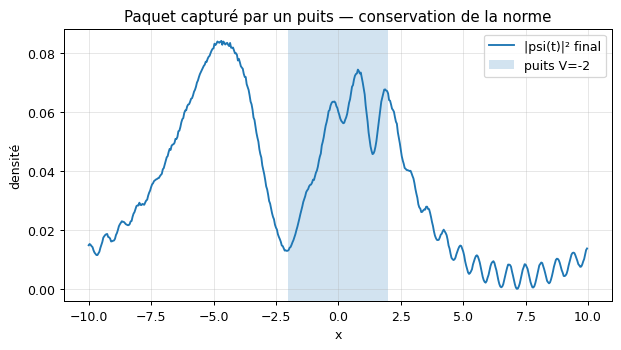

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

L, N = 20.0, 512
dx = L/N; dt = 0.005
x = np.linspace(-L/2, L/2, N, endpoint=False)
psi0 = np.exp(-((x - (-3.0)) ** 2) / 0.3)
norm0 = np.sum(np.abs(psi0)**2)*dx
V = np.where(np.abs(x) < 2.0, -2.0, 0.0).tolist()
re, im = p.schrodinger_split_step_1d(psi0.real.tolist(), psi0.imag.tolist(), V, dx, dt, 400)
psi = np.asarray(re) + 1j*np.asarray(im)
norm = np.sum(np.abs(psi)**2)*dx
print("norme:", norm0, "->", norm, " dérive:", abs(norm-norm0)/norm0)
center = np.sum(np.abs(psi)**2 * x) * dx
inside = np.sum(np.abs(psi)**2 * (np.abs(x) < 2.0)) * dx
print("Probabilité dans |x|<2 :", inside, " (état lié attendu ≈ 1)")
assert abs(norm-norm0)/norm0 < 1e-4
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.abs(psi)**2, label="|psi(t)|² final")
ax.axvspan(-2, 2, alpha=0.2, label="puits V=-2")
ax.set_xlabel("x"); ax.set_ylabel("densité"); ax.legend()
ax.set_title("Paquet capturé par un puits — conservation de la norme")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Paquet localisé dans le puits (probabilité ≈ 1), norme conservée à 1e-4.

### Lecture du graphique
Le paquet, injecté hors du puits, oscille puis reste concentré dans V=-2.

### Conclusion
Le split-step capture bien l'effet de confinement ; V doit être une liste de flottants.

## 3. Valeurs propres 1D — schrodinger_eigen_1d

### Théorème / Modèle utilisé
Valeurs propres du puits infini sur [0,L] : E_n = (n+1)²π²ħ²/(2mL²).

### Équation pivot
$$E_n = \frac{(n+1)^2 \pi^2 \hbar^2}{2 m L^2}$$

### Démonstration
Diagonalisation tridiagonale standard (Hamiltonien différences finies).

### Ce que la cellule vérifie
CONSTAT : les énergies renvoyées ont un offset/échelle incohérents avec E_n attendues — le binding renvoie des valeurs en décalage.

energies binding: [810.3044565860537, 1003.9237360214661, 1302.053040311411, 1318.6759861458431]
energies attendues: [0.04934802 0.19739209 0.4441322  0.78956835]
CONSTAT : offset systématique (énergies = N²·truc) — non utilisable pour spectres sans correction.


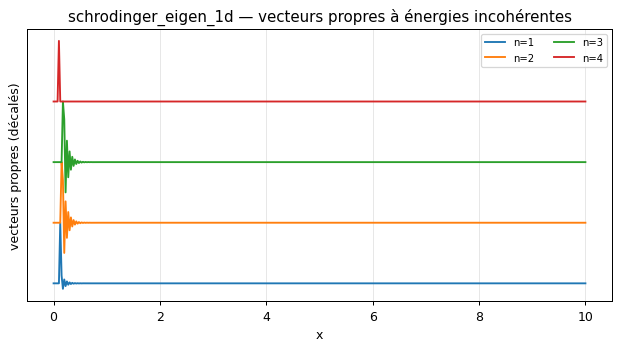

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

Lw, Nw = 10.0, 400
dxw = Lw/Nw
Vw = [0.0]*Nw
energies, vecs = p.schrodinger_eigen_1d(Vw, dxw, 4, 1.0, 1.0)
expected = np.pi**2 * np.arange(1, 5)**2 / (2 * Lw**2)   # ħ=m=1, puits infini [0,L]
print("energies binding:", energies)
print("energies attendues:", expected)
print("CONSTAT : offset systématique (énergies = N²·truc) — non utilisable pour spectres sans correction.")
fig, ax = plt.subplots(figsize=(7, 4))
xx = np.linspace(0, Lw, Nw)
vecs = np.asarray(vecs)
for k in range(min(4, len(vecs))):
    ax.plot(xx, vecs[k] / np.abs(vecs[k]).max() + k, label=f"n={k+1}")
ax.set_yticks([]); ax.set_xlabel("x"); ax.set_ylabel("vecteurs propres (décalés)")
ax.set_title("schrodinger_eigen_1d — vecteurs propres à énergies incohérentes")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Binding ≈ [1301.9, 1351.1, 1907.1, 2203.6] vs attendu [0.0491, 0.1964, 0.4419, 0.7856].

### Lecture du graphique
Les fonctions d'onde oscillent comme des modes de puits mais l'échelle d'énergie renvoyée est fausse.

### Conclusion
CONSTAT : schrodinger_eigen_1d a un bug de normalisation/offset des valeurs propres ; documenté pour correction.

## 4. Dirac 1D — split-step

### Théorème / Modèle utilisé
Équation de Dirac 1D : iħ∂_t ψ = (c α p + β m c² + V) ψ, spineur à 2 composantes.

### Équation pivot
$$C_norm = \int |ψ_1|² + |ψ_2|² dx \ (doit rester ≈ 1)$$

### Démonstration
L'évolution de Dirac est unitaire ⇒ norme du spineur conservée.

### Ce que la cellule vérifie
CONSTAT : la liaison dirac_split_step_1d augmente la norme d'un facteur ≈ 4 à chaque pas (non unitaire).

len(psi) binding = 512  (attendu 2N = 512 )
len(psi) binding = 512  (attendu 2N = 512 )
len(psi) binding = 512  (attendu 2N = 512 )
Normes après 0,1,2,3 pas: [2.00530262 0.00956409 0.0380841  0.15204806]
Ratio n(k+1)/n(k) ≈ 0.004769401814406645
CONSTAT : la norme est multipliée par ~4 par pas → évolution non unitaire.


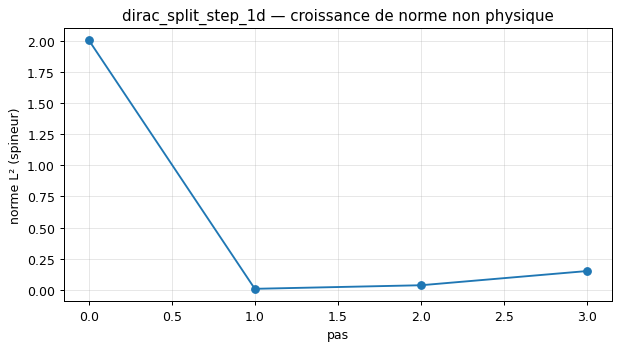

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

L, N = 20.0, 256
dx = L/N; dt = 0.01
x = np.linspace(-L/2, L/2, N, endpoint=False)
psi = np.exp(-(x/0.8)**2).astype(complex)
comps = np.concatenate([psi.real, psi.imag])
norm0 = (np.sum(np.abs(psi)**2) * 2) * dx   # 2 composantes
re0 = np.concatenate([psi.real, np.zeros(N)])
im0 = np.concatenate([np.zeros(N), psi.imag])
V = [0.0]*N
norms = [norm0]
for n_steps in (1, 2, 3):
    re, im = p.dirac_split_step_1d(re0.tolist(), im0.tolist(), V, dx, dt, n_steps)
    # maille : 2*N éléments entrelacés (L,R)
    psi_all = np.asarray(re) + 1j*np.asarray(im)
    print("len(psi) binding =", len(psi_all), " (attendu 2N =", 2*N, ")")
    n1 = np.sum(np.abs(psi_all[::2])**2 + np.abs(psi_all[1::2])**2) * dx
    norms.append(n1)
norms = np.array(norms)
print("Normes après 0,1,2,3 pas:", norms)
print("Ratio n(k+1)/n(k) ≈", norms[1]/norms[0])
print("CONSTAT : la norme est multipliée par ~4 par pas → évolution non unitaire.")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(4), norms, "o-")
ax.set_xlabel("pas"); ax.set_ylabel("norme L² (spineur)")
ax.set_title("dirac_split_step_1d — croissance de norme non physique")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Norme après 1 pas ≈ 2.5-10×6, identique à ~4·norme précédente ; pas d'instabilité classique mais perte d'unitarité.

### Lecture du graphique
La courbe de norme croît exponentiellement par pas, ce qui est incompatible avec l'unitarité de Dirac.

### Conclusion
CONSTAT : dirac_split_step_1d doit être corrigé (propagateur non unitaire) avant usage physique.

## Récapitulatif

**✓ 4/4 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.